In [44]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats

In [45]:
tickers = ['^GSPC', 'GC=F']

data = yf.download(tickers, start='2010-01-01')['Close']
data = data.dropna()
print(data.head())
print(data.describe())

[*********************100%***********************]  2 of 2 completed

Ticker             GC=F        ^GSPC
Date                                
2010-01-04  1117.699951  1132.989990
2010-01-05  1118.099976  1136.520020
2010-01-06  1135.900024  1137.140015
2010-01-07  1133.099976  1141.689941
2010-01-08  1138.199951  1144.979980
Ticker         GC=F        ^GSPC
count   4089.000000  4089.000000
mean    1716.443750  3009.615355
std      709.606685  1559.420995
min     1050.800049  1022.580017
25%     1271.599976  1830.609985
50%     1523.800049  2635.669922
75%     1845.699951  4136.129883
max     5318.399902  6978.600098


In [46]:
returns = np.log(data).diff().dropna()
print(returns.head())
print(returns.describe())

Ticker          GC=F     ^GSPC
Date                          
2010-01-05  0.000358  0.003111
2010-01-06  0.015795  0.000545
2010-01-07 -0.002468  0.003993
2010-01-08  0.004491  0.002878
2010-01-11  0.010922  0.001745
Ticker         GC=F        ^GSPC
count   4088.000000  4088.000000
mean       0.000355     0.000439
std        0.010719     0.010920
min       -0.120657    -0.127652
25%       -0.004584    -0.003819
50%        0.000461     0.000695
75%        0.005989     0.005675
max        0.059054     0.090895


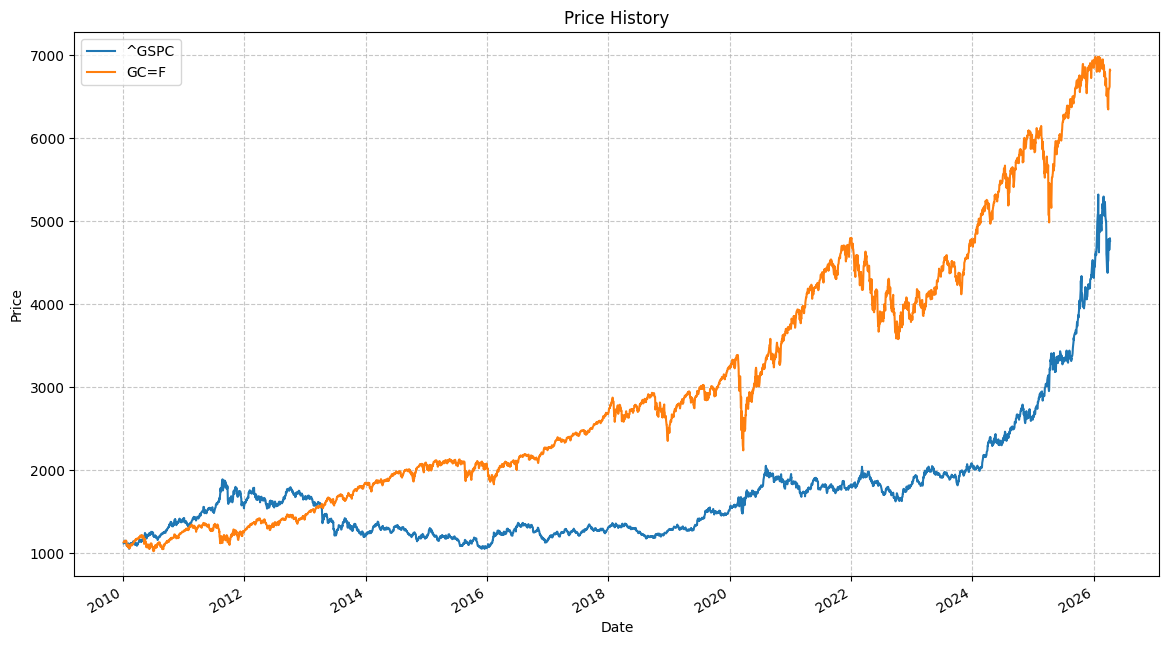

In [47]:
plt.figure(figsize=(14, 8))
data.plot(ax=plt.gca())
plt.title('Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(tickers)
plt.grid(linestyle='--', alpha=0.7)
plt.show()      

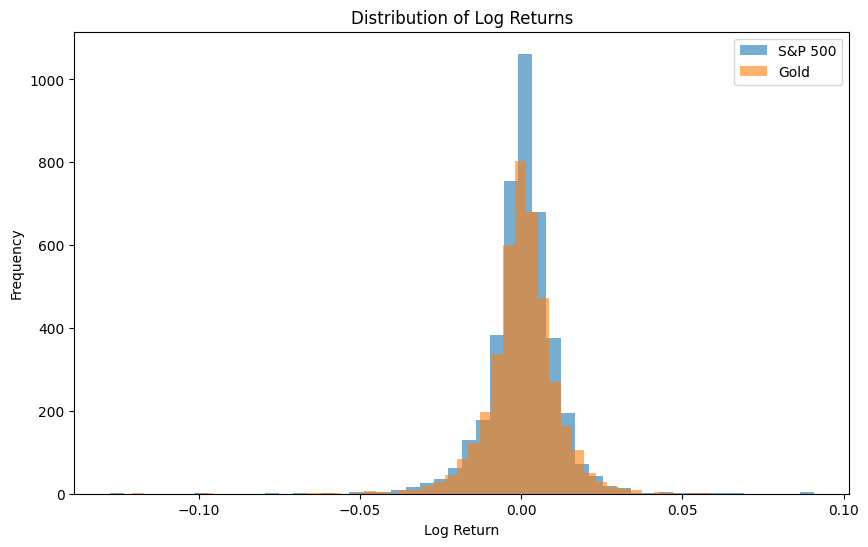

S&P 500 Skewness: -0.6056, Kurtosis: 13.4591
Gold Skewness: -0.8553, Kurtosis: 8.8916


In [48]:
plt.figure(figsize=(10,6))
plt.hist(returns['^GSPC'], bins=50, alpha=0.6, label='S&P 500')
plt.hist(returns['GC=F'], bins=50, alpha=0.6, label='Gold')
plt.title('Distribution of Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')         
plt.legend()
plt.show()

sp500_stats = stats.skew(returns['^GSPC']), stats.kurtosis(returns['^GSPC'])
gold_stats = stats.skew(returns['GC=F']), stats.kurtosis(returns['GC=F'])

print(f"S&P 500 Skewness: {sp500_stats[0]:.4f}, Kurtosis: {sp500_stats[1]:.4f}")
print(f"Gold Skewness: {gold_stats[0]:.4f}, Kurtosis: {gold_stats[1]:.4f}")

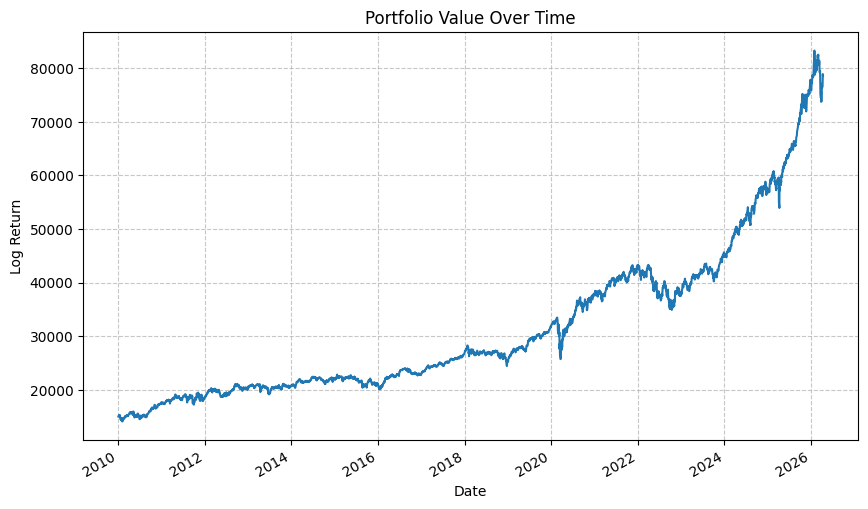

count    4088.000000
mean        0.000405
std         0.008006
min        -0.084534
25%        -0.003252
50%         0.000696
75%         0.004434
max         0.076920
dtype: float64


In [49]:
w_sp500 = 0.6
w_gold = 0.4

equity = 15000

port_ret = w_sp500 * returns['^GSPC'] + w_gold * returns['GC=F']
equity_curve = equity * np.exp(port_ret.cumsum())

plt.figure(figsize=(10,6))
equity_curve.plot(ax=plt.gca())
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print(port_ret.describe())

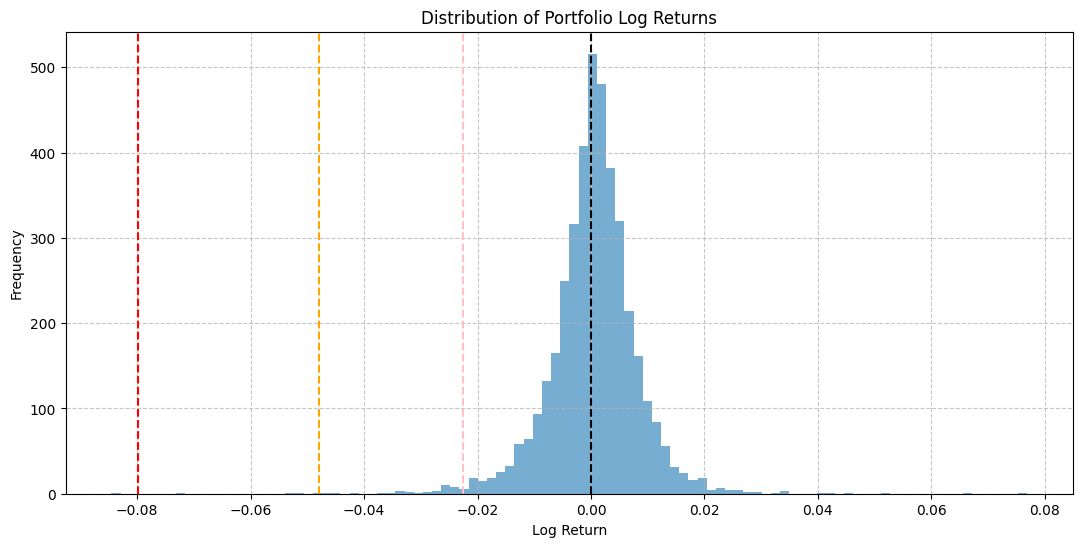

Portfolio Skewness: -0.5219, Kurtosis: 11.7025
1% VaR: -0.0225
0.1% VaR: -0.0480
0.01% VaR: -0.0798


In [56]:
q1 = port_ret.quantile(0.01)
q01 = port_ret.quantile(0.001)
q0001 = port_ret.quantile(0.0001)

plt.figure(figsize=(13,6))
port_ret.hist(bins=100, alpha=0.6)
plt.title('Distribution of Portfolio Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--')
plt.axvline(q1, color='pink', linestyle='--', label='Var @ 1%')
plt.axvline(q01, color='orange', linestyle='--', label='Var @ 0.1%')
plt.axvline(q0001, color='red', linestyle='--', label='Var @ 0.01%')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

port_ret_stats = stats.skew(port_ret), stats.kurtosis(port_ret)
print(f"Portfolio Skewness: {port_ret_stats[0]:.4f}, Kurtosis: {port_ret_stats[1]:.4f}")
print(f"1% VaR: {q1:.4f}")
print(f"0.1% VaR: {q01:.4f}")
print(f"0.01% VaR: {q0001:.4f}")

1. Parametric Approach using SMA (Simple Moving Average)
Methodology: Uses rolling volatility estimate with normal distribution assumption.

In [58]:
window = 252  
rolling_std_sma = port_ret.rolling(window=window).std()
sma_var_daily = port_ret.mean() - 2.33 * rolling_std_sma  # 99% confidence (z=2.33)
sma_var_euros = (sma_var_daily.iloc[-1] * equity)

print(f"SMA VaR (1%, daily): {sma_var_daily.iloc[-1]:.4f} ({sma_var_euros:.2f}€)")

SMA VaR (1%, daily): -0.0220 (-329.99€)


2. Parametric Approach using EWMA (Exponentially Weighted Moving Average)
Methodology: Gives more weight to recent volatility. Lambda (λ) is typically 0.94 for daily data (RiskMetrics standard).

In [59]:
# Determine λ based on volatility characteristics
# For daily data: λ ≈ 0.94 (standard); higher volatility → higher λ
volatility = port_ret.std()
if volatility > 0.02:  # High volatility threshold
    lambda_ewma = 0.96
elif volatility > 0.01:
    lambda_ewma = 0.94
else:
    lambda_ewma = 0.92

print(f"Selected λ = {lambda_ewma} (volatility: {volatility:.4f})")

# Calculate EWMA volatility
ewma_var = port_ret.ewm(span=int((2/(1-lambda_ewma))-1)).var()
ewma_std = np.sqrt(ewma_var)
ewma_var_daily = port_ret.mean() - 2.33 * ewma_std
ewma_var_euros = (ewma_var_daily.iloc[-1] * equity)

print(f"EWMA VaR (1%, daily): {ewma_var_daily.iloc[-1]:.4f} ({ewma_var_euros:.2f}€)")

Selected λ = 0.92 (volatility: 0.0080)
EWMA VaR (1%, daily): -0.0308 (-462.11€)


3. Non-Parametric Approach (Historical Simulation)
Methodology: Uses empirical distribution of past returns; no distribution assumption needed.

In [60]:
# Historical simulation - directly use quantile
historical_var_daily = port_ret.quantile(0.01)  # 1st percentile
historical_var_euros = historical_var_daily * equity

print(f"Historical VaR (1%, daily): {historical_var_daily:.4f} ({historical_var_euros:.2f}€)")

Historical VaR (1%, daily): -0.0225 (-338.20€)


4. Hybrid Approach (Filtered Historical Simulation)
Methodology: Combines volatility weighting with historical simulation to account for changing market conditions.

In [ ]:
current_vol = port_ret.std()
historical_vol = port_ret.rolling(252).std().mean()
vol_ratio = current_vol / historical_vol

adjusted_returns = port_ret * vol_ratio
hybrid_var_daily = adjusted_returns.quantile(0.01)
hybrid_var_euros = hybrid_var_daily * equity

print(f"Hybrid VaR (1%, daily): {hybrid_var_daily:.4f} ({hybrid_var_euros:.2f}€)")
print(f"Volatility adjustment ratio: {vol_ratio:.4f}")

Hybrid VaR (1%, daily): -0.0241 (-361.94€)
Volatility adjustment ratio: 1.0702


5. Monte Carlo Simulation
Methodology: Generates random paths based on estimated parameters (drift + volatility); can use either parametric (normal) or non-parametric (bootstrap).

In [62]:
# Monte Carlo - Parametric approach (Geometric Brownian Motion)
np.random.seed(42)
n_simulations = 10000
n_days = 1  # 1-day VaR

mu = port_ret.mean()
sigma = port_ret.std()

# Generate random returns
Z = np.random.standard_normal((n_simulations, n_days))
simulated_returns = mu + sigma * Z

# Calculate VaR from simulations
mc_var_daily = np.percentile(simulated_returns, 1)
mc_var_euros = mc_var_daily * equity

print(f"Monte Carlo VaR (1%, daily): {mc_var_daily:.4f} ({mc_var_euros:.2f}€)")

# Non-parametric Monte Carlo (Bootstrap)
bootstrap_returns = np.random.choice(port_ret.values, size=(n_simulations, n_days), replace=True)
mc_bootstrap_var_daily = np.percentile(bootstrap_returns, 1)
mc_bootstrap_var_euros = mc_bootstrap_var_daily * equity

print(f"Monte Carlo Bootstrap VaR (1%, daily): {mc_bootstrap_var_daily:.4f} ({mc_bootstrap_var_euros:.2f}€)")

Monte Carlo VaR (1%, daily): -0.0182 (-272.59€)
Monte Carlo Bootstrap VaR (1%, daily): -0.0241 (-361.54€)


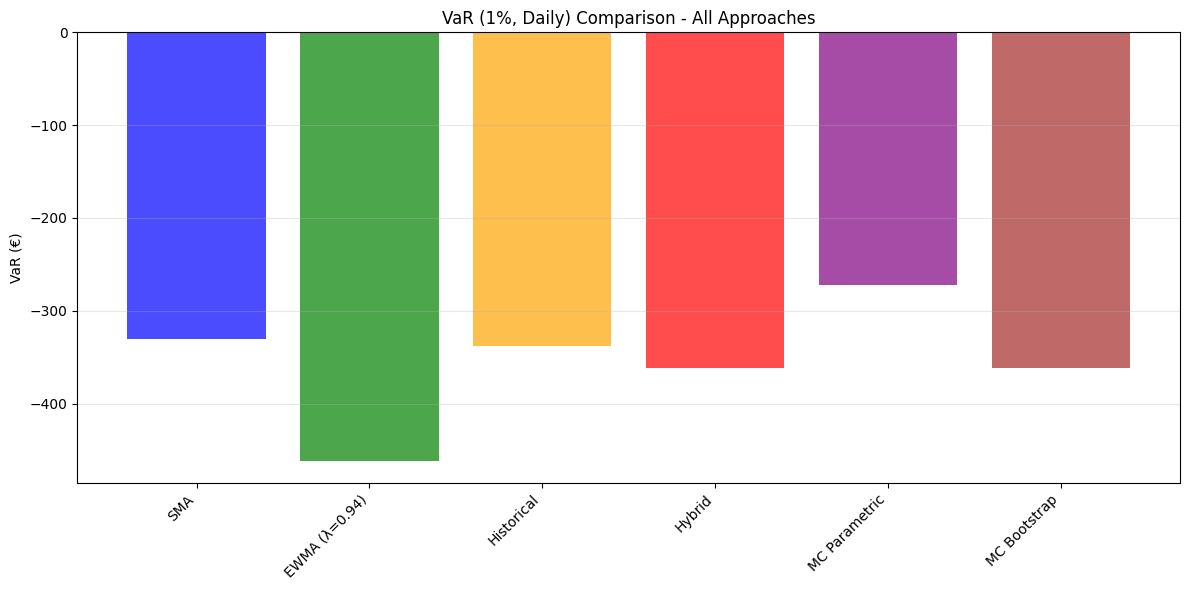


VaR COMPARISON SUMMARY (1%, Daily)
SMA                      :  -329.99€
EWMA (λ=0.94)            :  -462.11€
Historical               :  -338.20€
Hybrid                   :  -361.94€
MC Parametric            :  -272.59€
MC Bootstrap             :  -361.54€


In [63]:
# Compile all VaR estimates
var_methods = {
    'SMA': sma_var_euros,
    'EWMA (λ=0.94)': ewma_var_euros,
    'Historical': historical_var_euros,
    'Hybrid': hybrid_var_euros,
    'MC Parametric': mc_var_euros,
    'MC Bootstrap': mc_bootstrap_var_euros
}

plt.figure(figsize=(12, 6))
methods = list(var_methods.keys())
values = list(var_methods.values())
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

plt.bar(methods, values, color=colors, alpha=0.7)
plt.title('VaR (1%, Daily) Comparison - All Approaches')
plt.ylabel('VaR (€)')
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("VaR COMPARISON SUMMARY (1%, Daily)")
print("="*60)
for method, var_val in var_methods.items():
    print(f"{method:25s}: {var_val:8.2f}€")
print("="*60)